## 1.Configuration and Imports

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score,
)
from hybrid_detector import (
    load_hybrid_components, load_models,
    hybrid_predict, hybrid_predict_proba,
    INV_LABEL_MAP,
)

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

LABEL_MAP = {
    "normal": 0,
    "no_pkce_accepted": 1,
    "no_pkce_rejected": 2,
    "pkce_downgrade": 3,
    "redirect_flaw_strict": 4,
    "redirect_flaw_misconfig": 5,
    "refresh_misuse_rejected": 6,
    "refresh_misuse_stolen": 7,
}
INV_LABEL_MAP_LOCAL = {v: k for k, v in LABEL_MAP.items()}

print("Imports OK")

Imports OK


## 2.Load Dataset

In [ ]:
df = pd.read_csv("merged_dataset.csv")
df["run"] = df["run"].astype(int)

full_features = [c for c in df.columns if c.startswith("x")]
rule_features = [c for c in df.columns if c.startswith("rule_") and c != "rule_label"]
munonye_features = [f"x{i}" for i in range(1, 33)]

X_full = df[full_features]
X_rules = df[rule_features]
X_32 = df[munonye_features]
y = df["label"]

target_names = [INV_LABEL_MAP_LOCAL[i] for i in sorted(INV_LABEL_MAP_LOCAL)]
class_names = target_names

print(f"Dataset: {len(df)} traces")
print(f"Full features: {len(full_features)}")
print(f"Rule Features: {len(rule_features)}")
print(f"Munonye Features: {len(munonye_features)}")
print(f"Classes: {target_names}")
print(f"Label distribution:\n{df['scenario'].value_counts().to_string()}")

Dataset: 1240 traces
Full features: 38
Rule Features: 5
Munonye Features: 32
Classes: ['normal', 'no_pkce_accepted', 'no_pkce_rejected', 'pkce_downgrade', 'redirect_flaw_strict', 'redirect_flaw_misconfig', 'refresh_misuse_rejected', 'refresh_misuse_stolen']
Label distribution:
scenario
no_pkce_accepted           155
no_pkce_rejected           155
normal                     155
pkce_downgrade             155
redirect_flaw_misconfig    155
redirect_flaw_strict       155
refresh_misuse_rejected    155
refresh_misuse_stolen      155


## 3.Train all models

In [ ]:
PARAM_GRID = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

def train_gbc(X, y, name: str):
    """Train a GradientBoostingClassifier with grid search.
    Uses 70/20/10 split: train/test/tune.
    Saves model to models/<name>.joblib and prints evaluation on test set."""
    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)
    X_train, X_tune, y_train, y_tune = train_test_split(
        X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

    # Grid search on tuning set
    gs = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        PARAM_GRID, cv=3, scoring="f1_macro", n_jobs=-1,
    )
    gs.fit(X_tune, y_tune)
    best = gs.best_params_
    print(f"[{name}] best params: {best}")

    # Train on full training set with best params
    model = GradientBoostingClassifier(**best, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n[{name}] Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\n[{name}] Classification report:")
    print(classification_report(
        y_test, y_pred, target_names=target_names, zero_division=0))

    try:
        auroc = roc_auc_score(
            y_test, model.predict_proba(X_test),
            multi_class="ovr", average="macro")
        print(f"[{name}] Macro AUROC: {auroc:.4f}")
    except Exception as e:
        print(f"[{name}] AUROC failed: {e}")

    path = MODELS_DIR / f"{name}.joblib"
    joblib.dump(model, path)
    print(f"[{name}] Saved to {path}\n")
    return model


print("Training GBC_rules (rule flags only — baseline)...")
gbc_rules = train_gbc(X_rules, y, "gbc_rules")

print("=" * 60)
print("Training GBC_full (38-feature extended set)...")
gbc_full = train_gbc(X_full, y, "gbc_full")

print("=" * 60)
print("Training GBC_32 (Munonye 32-feature baseline — RQ3)...")
gbc_32 = train_gbc(X_32, y, "gbc_32_munonye")

print("=" * 60)
print("All models trained and saved.")

Training GBC_rules (rule flags only — baseline)...
[gbc_rules] best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}

[gbc_rules] Confusion matrix:
[[31  0  0  0  0  0  0  0]
 [ 0 15 16  0  0  0  0  0]
 [ 0 12 19  0  0  0  0  0]
 [ 0 12 12  7  0  0  0  0]
 [ 0  0  0  0 31  0  0  0]
 [ 0  0  0  0  0 31  0  0]
 [ 0  0  0  0  0  0 31  0]
 [ 0  0  0  0  0  0 31  0]]

[gbc_rules] Classification report:
                         precision    recall  f1-score   support

                 normal       1.00      1.00      1.00        31
       no_pkce_accepted       0.38      0.48      0.43        31
       no_pkce_rejected       0.40      0.61      0.49        31
         pkce_downgrade       1.00      0.23      0.37        31
   redirect_flaw_strict       1.00      1.00      1.00        31
redirect_flaw_misconfig       1.00      1.00      1.00        31
refresh_misuse_rejected       0.50      1.00      0.67        31
  refresh_misuse_stolen       0.00      0.00      0.00     

## 4.Hybrid detector evaluation

In [ ]:
df_eval, X_rules_eval, X_full_eval, y_true = load_hybrid_components()
gbc_rules_loaded, gbc_full_loaded = load_models()

y_pred_hybrid = hybrid_predict(X_rules_eval, X_full_eval,
                                gbc_rules_loaded, gbc_full_loaded)
proba_hybrid  = hybrid_predict_proba(X_rules_eval, X_full_eval,
                                      gbc_rules_loaded, gbc_full_loaded)

labels = sorted(INV_LABEL_MAP)

print("Hybrid Detector — Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_hybrid))
print()
print("Hybrid Detector — Classification Report:")
print(classification_report(
    y_true, y_pred_hybrid,
    labels=labels,
    target_names=[INV_LABEL_MAP[i] for i in labels],
    zero_division=0,
))

if proba_hybrid is not None:
    try:
        auroc = roc_auc_score(y_true, proba_hybrid,
                              multi_class="ovr", average="macro")
        print(f"Macro AUROC (Hybrid): {auroc:.4f}")
    except Exception as e:
        print(f"AUROC failed: {e}")

Hybrid Detector — Confusion Matrix:
[[155   0   0   0   0   0   0   0]
 [  0 128  27   0   0   0   0   0]
 [  0  13 142   0   0   0   0   0]
 [  0   0   0 155   0   0   0   0]
 [  0   0   0   0 155   0   0   0]
 [  0   0   0   0   0 155   0   0]
 [  0   0   0   0   0   0 155   0]
 [  0   0   0   0   0   0   0 155]]

Hybrid Detector — Classification Report:
                         precision    recall  f1-score   support

                 normal       1.00      1.00      1.00       155
       no_pkce_accepted       0.91      0.83      0.86       155
       no_pkce_rejected       0.84      0.92      0.88       155
         pkce_downgrade       1.00      1.00      1.00       155
   redirect_flaw_strict       1.00      1.00      1.00       155
redirect_flaw_misconfig       1.00      1.00      1.00       155
refresh_misuse_rejected       1.00      1.00      1.00       155
  refresh_misuse_stolen       1.00      1.00      1.00       155

               accuracy                           0.97

## 5. Model Comparison Chart

In [ ]:
def get_metrics(y_true, y_pred, y_proba=None):
    """Compute macro-averaged classification metrics for a model."""
    out = {
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Macro F1":  round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "AUROC":     None,
    }
    if y_proba is not None:
        try:
            out["AUROC"] = round(
                roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"), 4)
        except Exception:
            pass
    return out


# Generate predictions and probabilities for all models on the full dataset
y_pred_rules  = gbc_rules.predict(X_rules)
y_pred_32     = gbc_32.predict(X_32)
y_pred_full   = gbc_full.predict(X_full)

proba_rules   = gbc_rules.predict_proba(X_rules)
proba_32      = gbc_32.predict_proba(X_32)
proba_full    = gbc_full.predict_proba(X_full)

results = {
    "GBC_rules":        get_metrics(y, y_pred_rules,  proba_rules),
    "GBC_32 (Munonye)": get_metrics(y, y_pred_32,     proba_32),
    "GBC_full":         get_metrics(y, y_pred_full,   proba_full),
    "Hybrid":           get_metrics(y_true, y_pred_hybrid, proba_hybrid),
}

results_df = pd.DataFrame(results).T
print("Model Performance Summary:")
print(results_df.to_string())


Model Performance Summary:
                  Accuracy  Macro F1  Precision  Recall   AUROC
GBC_rules           0.6661    0.6203     0.6583  0.6661  0.9419
GBC_32 (Munonye)    0.7613    0.7169     0.6999  0.7613  0.9665
GBC_full            0.9677    0.9677     0.9685  0.9677  0.9986
Hybrid              0.9677    0.9677     0.9685  0.9677  0.9986


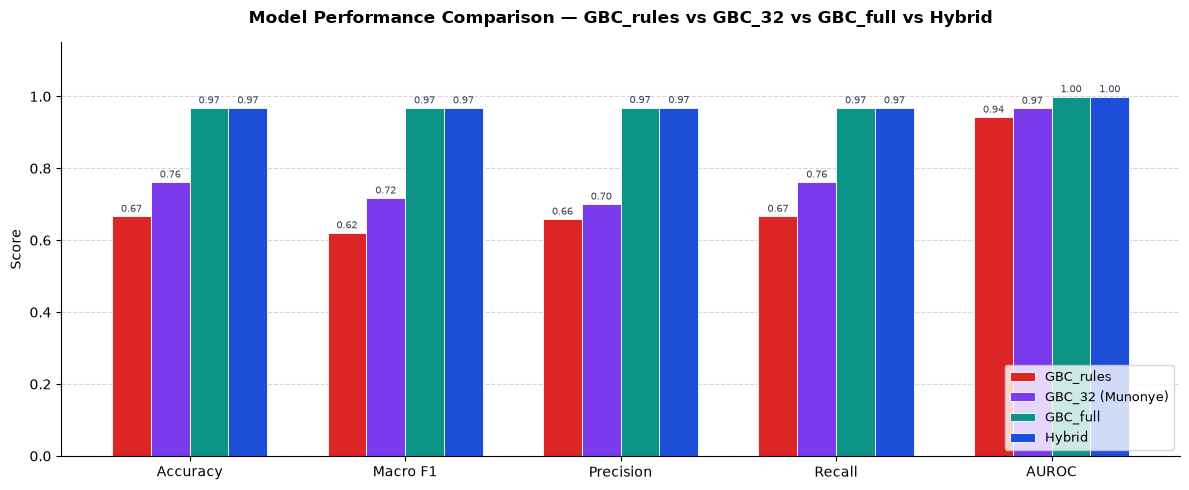

Saved model_comparison.png


In [ ]:
metrics  = ["Accuracy", "Macro F1", "Precision", "Recall", "AUROC"]
models   = list(results.keys())
colours  = ["#dc2626", "#7c3aed", "#0d9488", "#1d4ed8"]

x     = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))

for i, (model, colour) in enumerate(zip(models, colours)):
    vals = [results[model].get(m) or 0 for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=colour, edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.006,
                    f"{val:.2f}", ha="center", va="bottom",
                    fontsize=7.5, color="#374151")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=10)
ax.set_title(
    "Model Performance Comparison — GBC_rules vs GBC_32 vs GBC_full vs Hybrid",
    fontsize=12, fontweight="bold", pad=14,
)
ax.legend(loc="lower right", fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved model_comparison.png")


## 6.SHAP Feature Importance for gbc_full (all 38 features)

Background dataset has 1240 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1240 when initializing the masker.


[SHAP] Computing for gbc_full — may take ~1-2 minutes...


PermutationExplainer explainer: 1241it [08:39,  2.39it/s]                          
C:\Users\Pradhyumna\AppData\Local\Temp\ipykernel_30932\1124277239.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_full,


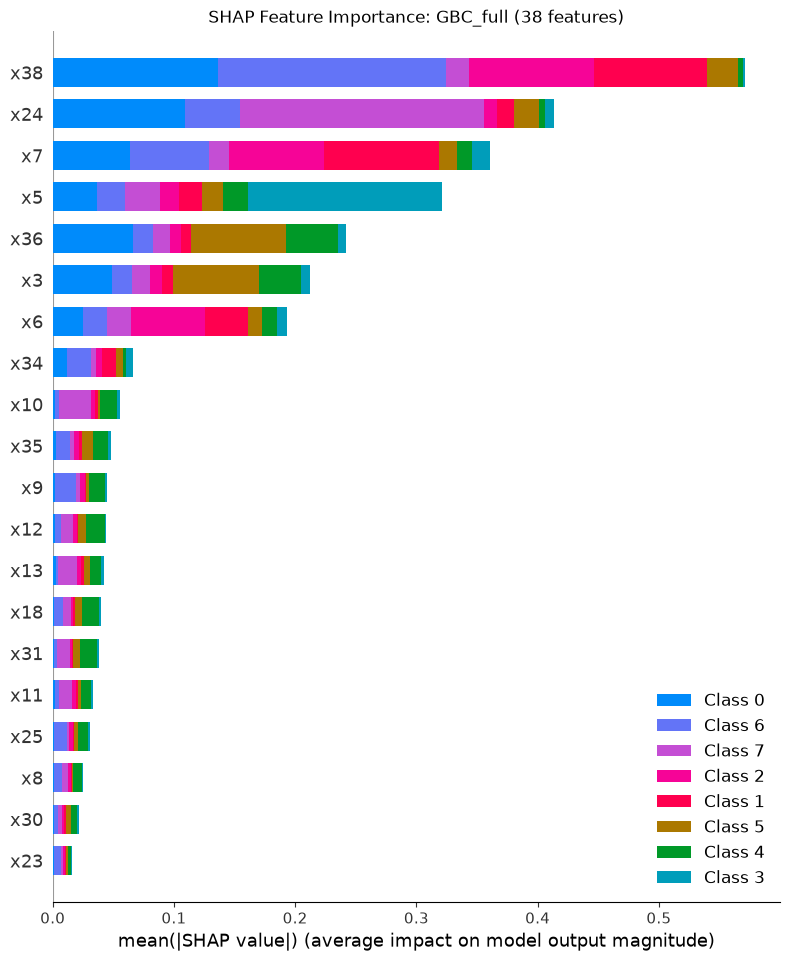

Saved shap_gbc_full_summary.png


In [ ]:
print("[SHAP] Computing for gbc_full — may take ~1-2 minutes...")
explainer_full   = shap.Explainer(gbc_full.predict_proba, X_full)
shap_values_full = explainer_full(X_full)

plt.figure()
shap.summary_plot(shap_values_full, X_full,
                  feature_names=full_features,
                  show=False, plot_type="bar")
plt.title("SHAP Feature Importance: GBC_full (38 features)")
plt.savefig("shap_gbc_full_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_gbc_full_summary.png")

In [ ]:
# Save per-feature per-class SHAP values to CSV
mean_abs_full = np.abs(shap_values_full.values).mean(axis=0)
shap_table_full = pd.DataFrame(mean_abs_full,
                                index=full_features,
                                columns=class_names)
shap_table_full["total"] = shap_table_full.sum(axis=1)
shap_table_full = shap_table_full.sort_values("total", ascending=False)
shap_table_full.round(4).to_csv("shap_gbc_full_values.csv")
print("Saved shap_gbc_full_values.csv")
shap_table_full.round(3)

Saved shap_gbc_full_values.csv


,normal,no_pkce_accepted,no_pkce_rejected,pkce_downgrade,redirect_flaw_strict,redirect_flaw_misconfig,refresh_misuse_rejected,refresh_misuse_stolen,total
x38,0.137,0.093,0.103,0.002,0.004,0.026,0.187,0.019,0.571
x24,0.109,0.014,0.010,0.007,0.005,0.021,0.045,0.202,0.413
x7,0.064,0.094,0.078,0.014,0.012,0.015,0.065,0.016,0.361
x5,0.036,0.019,0.016,0.161,0.020,0.018,0.023,0.029,0.321
x36,0.066,0.009,0.009,0.007,0.043,0.078,0.016,0.014,0.242
x3,0.049,0.009,0.009,0.007,0.035,0.071,0.017,0.015,0.212
x6,0.025,0.036,0.061,0.008,0.012,0.011,0.021,0.020,0.193
x34,0.011,0.011,0.005,0.005,0.003,0.005,0.020,0.004,0.066
x10,0.002,0.002,0.003,0.002,0.014,0.002,0.003,0.027,0.056
x35,0.003,0.002,0.004,0.002,0.013,0.009,0.012,0.003,0.048


## 7.SHAP Feature Importance for gbc_32_munonye (32 features)

[SHAP] Computing for gbc_32 — may take ~1-2 minutes...


Background dataset has 1240 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1240 when initializing the masker.
PermutationExplainer explainer: 1241it [08:54,  2.28it/s]                          
C:\Users\Pradhyumna\AppData\Local\Temp\ipykernel_30932\774141750.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_32, X_32,


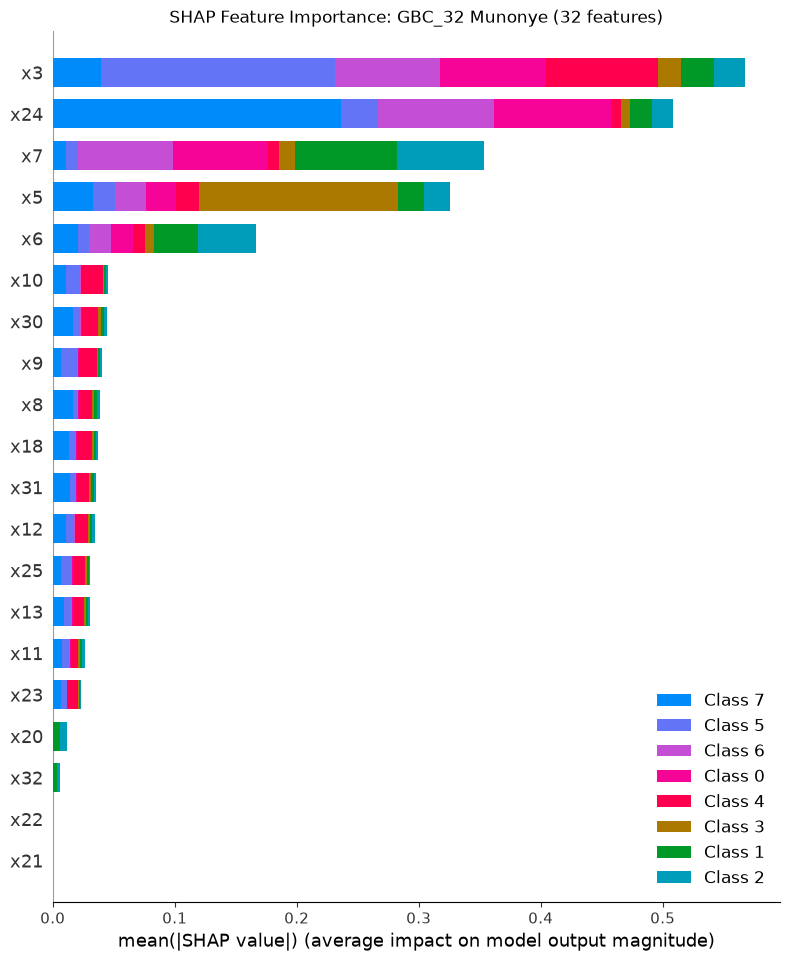

Saved shap_gbc_32_munonye_summary.png


In [ ]:
print("[SHAP] Computing for gbc_32 — may take ~1-2 minutes...")
explainer_32   = shap.Explainer(gbc_32.predict_proba, X_32)
shap_values_32 = explainer_32(X_32)

plt.figure()
shap.summary_plot(shap_values_32, X_32,
                  feature_names=munonye_features,
                  show=False, plot_type="bar")
plt.title("SHAP Feature Importance: GBC_32 Munonye (32 features)")
plt.savefig("shap_gbc_32_munonye_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_gbc_32_munonye_summary.png")

In [ ]:
mean_abs_32 = np.abs(shap_values_32.values).mean(axis=0)
shap_table_32 = pd.DataFrame(mean_abs_32,
                              index=munonye_features,
                              columns=class_names)
shap_table_32["total"] = shap_table_32.sum(axis=1)
shap_table_32 = shap_table_32.sort_values("total", ascending=False)
shap_table_32.round(4).to_csv("shap_gbc_32_munonye_values.csv")
print("Saved shap_gbc_32_munonye_values.csv")
shap_table_32.round(3)

Saved shap_gbc_32_munonye_values.csv


,normal,no_pkce_accepted,no_pkce_rejected,pkce_downgrade,redirect_flaw_strict,redirect_flaw_misconfig,refresh_misuse_rejected,refresh_misuse_stolen,total
x3,0.086,0.027,0.026,0.019,0.092,0.192,0.086,0.039,0.568
x24,0.096,0.018,0.017,0.007,0.008,0.030,0.096,0.236,0.508
x7,0.078,0.083,0.072,0.013,0.009,0.009,0.078,0.011,0.354
x5,0.025,0.021,0.021,0.163,0.019,0.019,0.025,0.033,0.326
x6,0.018,0.036,0.047,0.008,0.010,0.009,0.018,0.021,0.167
x10,0.001,0.001,0.001,0.001,0.018,0.012,0.001,0.011,0.045
x30,0.001,0.003,0.002,0.002,0.013,0.006,0.001,0.016,0.044
x9,0.001,0.001,0.002,0.001,0.014,0.013,0.001,0.007,0.040
x8,0.001,0.002,0.002,0.002,0.011,0.003,0.001,0.017,0.039
x18,0.001,0.002,0.002,0.001,0.013,0.005,0.001,0.014,0.037


## 8.RFC 9700 Feature Contribution (RQ3)

In [1]:
rfc9700_features = [f"x{i}" for i in range(33, 39)]

rfc9700_importance = shap_table_full.loc[
    shap_table_full.index.isin(rfc9700_features), "total"
].sum()
total_importance = shap_table_full["total"].sum()

print(f"Total SHAP importance (all 38 features):         {total_importance:.4f}")
print(f"SHAP importance from RFC 9700 features x33-x38:  {rfc9700_importance:.4f}")
print(f"Proportion from RFC 9700 extensions:             "
      f"{rfc9700_importance / total_importance * 100:.1f}%")
print()
print("RFC 9700 feature importances (sorted):")
print(shap_table_full.loc[
    shap_table_full.index.isin(rfc9700_features), ["total"]
].round(4).to_string())

print()
print("F1 comparison (from model training above):")
print(f"  GBC_32 (Munonye 32 features): {results['GBC_32 (Munonye)']['Macro F1']:.4f}")
print(f"  GBC_full (38 features):       {results['GBC_full']['Macro F1']:.4f}")
print(f"  Improvement:              "
      f"+{results['GBC_full']['Macro F1'] - results['GBC_32 (Munonye)']['Macro F1']:.4f}")


NameError: name 'shap_table_full' is not defined